# EDA — cleaned movies and ratings

Explore the cleaned movie table from `03_clean_movies.ipynb` before choosing the final encodings. Compare raw and log numeric fields, check genres, companies, countries, and language, and compare director and cast film counts with rating track records. Plots cover distributions, co-occurrence, top-X coverage, and how each group lines up with the mean rating. `n_ratings` describes popularity here and is not a movie feature.

## 1. Load the cleaned movies

List columns are JSON text. Parse them back into Python lists.

In [83]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [84]:
ROOT = Path("..")
PROCESSED = ROOT / "data" / "processed"
CHUNKSIZE = 2_000_000
MIN_MONEY = 1_000
NETFLIX_END_YEAR = 2005
US = "United States of America"
SHRINK = 3
LIST_COLS = [
    "genre_names",
    "company_names",
    "country_names",
    "language_names",
    "cast_names",
]

In [85]:
def parse_list(val):
    if pd.isna(val) or val == "":
        return []
    return json.loads(val)

In [86]:
movies = pd.read_csv(PROCESSED / "movies_cleaned.csv")
for col in LIST_COLS:
    movies[col] = movies[col].map(parse_list)

In [87]:
# Raw and log versions of the numeric fields, compared below. 05 recomputes the ones it keeps.
movies["movie_age"] = NETFLIX_END_YEAR - movies["year"]
for raw_col in ["budget", "revenue", "runtime"]:
    movies[f"{raw_col}_log"] = np.log1p(movies[raw_col])
movies["movie_age_log"] = np.where(movies["movie_age"] >= 0, np.log1p(movies["movie_age"]), np.nan)
positive_money = (movies["budget"] > 0) & (movies["revenue"] > 0)
movies["roi"] = np.where(positive_money, movies["revenue"] / movies["budget"], np.nan)
movies["log_roi"] = np.where(positive_money, np.log(movies["revenue"]) - np.log(movies["budget"]), np.nan)

In [88]:
print(movies.shape)
movies.head(2)

(1322, 20)


,netflix_movie_id,title,year,budget,original_language,revenue,runtime,genre_names,company_names,country_names,language_names,cast_names,director,movie_age,budget_log,revenue_log,runtime_log,movie_age_log,roi,log_roi
0,30,Something's Gotta Give,2003.0,80000000,en,266728738,128.0,"[Drama, Comedy, Romance]","[Columbia Pictures Corporation, Waverly Films,...",[United States of America],"[Français, English]","[Jack Nicholson, Diane Keaton, Keanu Reeves, F...",Nancy Meyers,2.0,18.197537,19.401743,4.859812,1.098612,3.334109,1.204206
1,55,Jade,1995.0,50000000,en,9851610,95.0,"[Action, Thriller, Mystery, Romance]",[Paramount Pictures],[United States of America],[English],"[David Caruso, Linda Fiorentino, Chazz Palmint...",William Friedkin,10.0,17.727534,16.103146,4.564348,2.397895,0.197032,-1.624388


## 2. Aggregate ratings

Stream `ratings.csv` in chunks. Keep ratings whose movie is in the cleaned table, then build per-movie and per-user sums. The per-movie standard deviation uses those sums, so the full ratings file is not held in memory.

In [89]:
def accumulate(left, right):
    if left is None:
        return right
    return left.add(right, fill_value=0)


def sum_ratings(chunk, by):
    return chunk.groupby(by).agg(
        rating_sum=("rating", "sum"),
        rating_sq=("rating_sq", "sum"),
        n_ratings=("rating", "count"),
    )

In [90]:
movie_ids = set(movies["netflix_movie_id"].astype(int))
rating_cols = ["netflix_movie_id", "rater_id", "rating"]
rating_dtype = {"netflix_movie_id": "int32", "rater_id": "int32", "rating": "int8"}
movie_acc = user_acc = None
rating_counts = pd.Series(0, index=[1, 2, 3, 4, 5], dtype="int64")
n_ratings_total = 0
rating_sum_total = 0

In [91]:
for chunk in pd.read_csv(
    PROCESSED / "ratings.csv",
    usecols=rating_cols,
    dtype=rating_dtype,
    chunksize=CHUNKSIZE,
):
    chunk = chunk[chunk["netflix_movie_id"].isin(movie_ids)]
    if chunk.empty:
        continue
    rating_counts = rating_counts.add(chunk["rating"].value_counts(), fill_value=0)
    n_ratings_total += len(chunk)
    rating_sum_total += int(chunk["rating"].sum())
    chunk["rating_sq"] = chunk["rating"].astype("float64") ** 2
    movie_acc = accumulate(movie_acc, sum_ratings(chunk, "netflix_movie_id"))
    user_acc = accumulate(user_acc, sum_ratings(chunk, "rater_id"))

print(f"ratings on cleaned movies: {n_ratings_total:,}")
print(f"movies with ratings: {len(movie_acc):,} | users: {len(user_acc):,}")

ratings on cleaned movies: 51,559,146
movies with ratings: 1,322 | users: 463,656


In [92]:
def add_mean_std(stats):
    stats = stats.copy()
    stats["avg_rating"] = stats["rating_sum"] / stats["n_ratings"]
    # Sample standard deviation; undefined when a movie or user has one rating.
    var = (stats["rating_sq"] - stats["rating_sum"] ** 2 / stats["n_ratings"]) / (
        stats["n_ratings"] - 1
    )
    stats["rating_std"] = np.sqrt(var.where(stats["n_ratings"] >= 2))
    return stats

In [93]:
movie_stats = add_mean_std(movie_acc)
user_stats = add_mean_std(user_acc)
movies = movies.merge(
    movie_stats[["avg_rating", "rating_std", "n_ratings"]],
    left_on="netflix_movie_id",
    right_index=True,
    how="left",
)

In [94]:
print("movies with no ratings:", int(movies["avg_rating"].isna().sum()))
movies[["avg_rating", "rating_std", "n_ratings"]].describe()

movies with no ratings: 0


,avg_rating,rating_std,n_ratings
count,1322.000000,1322.000000,1322.000000
mean,3.446361,1.013766,39000.866868
std,0.381999,0.092290,40003.856104
min,1.945851,0.713283,109.000000
25%,3.195234,0.952210,9665.500000
50%,3.460301,1.006590,24390.500000
75%,3.712175,1.072971,55385.750000
max,4.504484,1.327419,232809.000000


## 3. Data quality

Check duplicates, empty lists, zero runtime, and budget or revenue under 1000$.
Zeros were already removed in `03_clean_movies.ipynb`. The remaining amounts under 1000$ are entry errors. They stay in this table so the rate is visible, notebook 05 drops them.

In [95]:
print("duplicate netflix_movie_id:", int(movies["netflix_movie_id"].duplicated().sum()))
print("missing director:", int(movies["director"].isna().sum()))
for col in LIST_COLS:
    print(f"empty {col}:", int(movies[col].map(len).eq(0).sum()))

tiny = (movies["budget"] < MIN_MONEY) | (movies["revenue"] < MIN_MONEY)
print("budget or revenue under $1,000:", int(tiny.sum()))
print("runtime == 0:", int((movies["runtime"] == 0).sum()))
movies.loc[tiny, ["title", "year", "budget", "revenue"]].sort_values("budget").head(12)

duplicate netflix_movie_id: 0
missing director: 0
empty genre_names: 0
empty company_names: 14
empty country_names: 5
empty language_names: 1
empty cast_names: 0
budget or revenue under $1,000: 8
runtime == 0: 0


,title,year,budget,revenue
124,Modern Times,1936.0,1,8500000
111,A Farewell to Arms,1932.0,4,25
963,The Prophecy,1995.0,8,16
741,Angela's Ashes,1999.0,25,13
904,Rugrats in Paris: The Movie,2000.0,30,103
1071,In the Cut,2003.0,12000000,23
12,The Cookout,2004.0,16000000,12
325,Chasing Liberty,2004.0,23000000,12


## 4. Per-movie rating distributions

`avg_rating` is the prediction target. `rating_std` is the polarization measure. `n_ratings` says how reliable the mean is. The last panel plots the mean against the spread.

In [96]:
rated = movies.dropna(subset=["avg_rating"]).copy()
stat_cols = ["avg_rating", "rating_std", "n_ratings"]

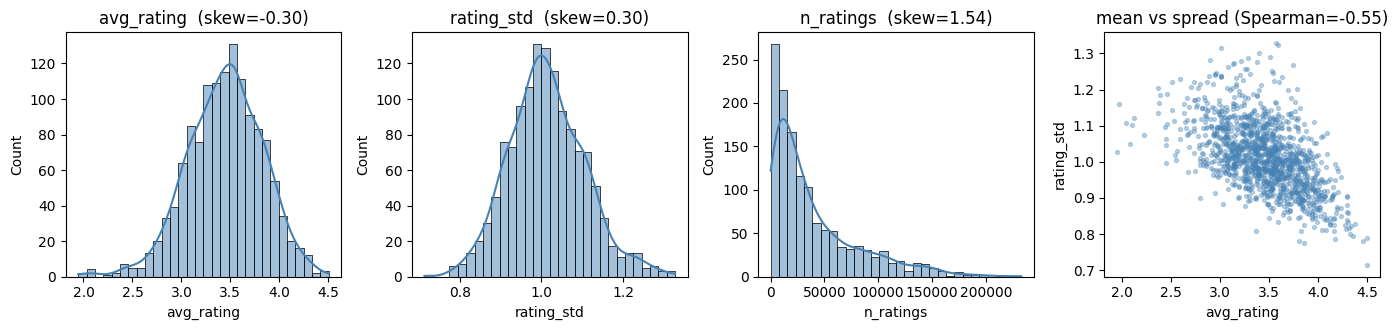

In [97]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, col in zip(axes, stat_cols):
    sns.histplot(rated[col].dropna(), bins=30, kde=True, color="steelblue", ax=ax)
    ax.set_title(f"{col}  (skew={rated[col].skew():.2f})")
rho = rated["avg_rating"].corr(rated["rating_std"], method="spearman")
axes[3].scatter(rated["avg_rating"], rated["rating_std"], s=8, alpha=0.35, color="steelblue")
axes[3].set_xlabel("avg_rating")
axes[3].set_ylabel("rating_std")
axes[3].set_title(f"mean vs spread (Spearman={rho:.2f})")
fig.tight_layout()
plt.show()

## 5. Ratings — global and per-user patterns

Global 1–5 histogram, then buckets of how many films each user rates, how widely they use the scale, and their mean score.

In [98]:
print(
    f"users: {len(user_stats):,} | "
    f"median ratings/user: {user_stats['n_ratings'].median():.0f} | "
    f"mean rating overall: {rating_sum_total / n_ratings_total:.3f}"
)

users: 463,656 | median ratings/user: 59 | mean rating overall: 3.612


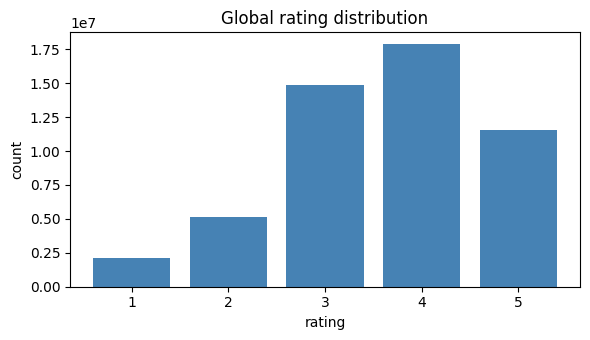

In [99]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color="steelblue")
ax.set_xlabel("rating")
ax.set_ylabel("count")
ax.set_title("Global rating distribution")
fig.tight_layout()
plt.show()

In [100]:
def plot_bucket_counts(series, bins, labels, title, xlabel):
    buckets = pd.cut(series, bins=bins, labels=labels, right=True, include_lowest=True)
    counts = buckets.value_counts().reindex(labels)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(counts.index.astype(str), counts.values, color="steelblue")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("users")
    ax.set_title(title)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    plt.show()
    return counts

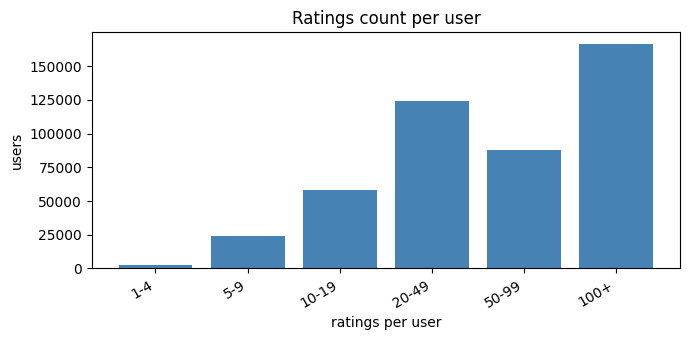

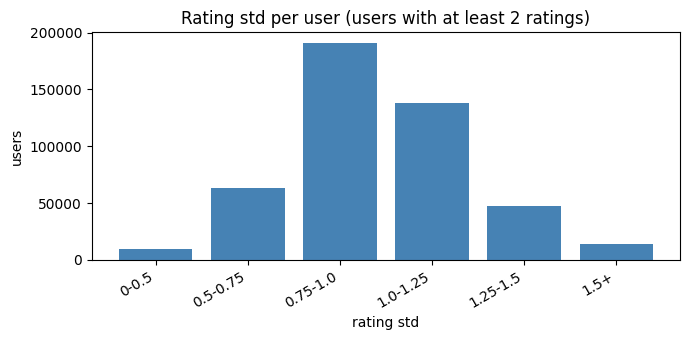

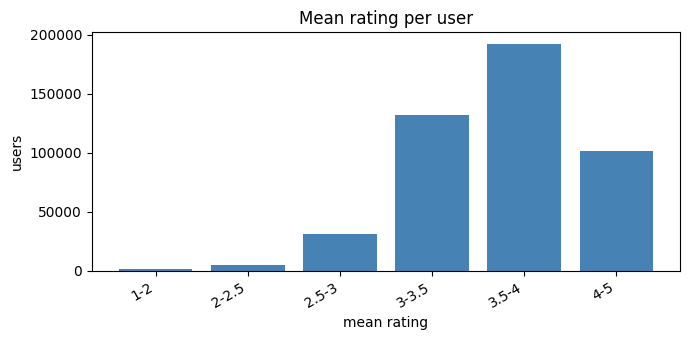

avg_rating
1-2        1344
2-2.5      4965
2.5-3     31431
3-3.5    132079
3.5-4    192506
4-5      101331
Name: count, dtype: int64

In [101]:
plot_bucket_counts(
    user_stats["n_ratings"],
    bins=[0.5, 4, 9, 19, 49, 99, np.inf],
    labels=["1-4", "5-9", "10-19", "20-49", "50-99", "100+"],
    title="Ratings count per user",
    xlabel="ratings per user",
)
plot_bucket_counts(
    user_stats["rating_std"].dropna(),
    bins=[-0.01, 0.5, 0.75, 1.0, 1.25, 1.5, np.inf],
    labels=["0-0.5", "0.5-0.75", "0.75-1.0", "1.0-1.25", "1.25-1.5", "1.5+"],
    title="Rating std per user (users with at least 2 ratings)",
    xlabel="rating std",
)
plot_bucket_counts(
    user_stats["avg_rating"],
    bins=[0.99, 2.0, 2.5, 3.0, 3.5, 4.0, 5.01],
    labels=["1-2", "2-2.5", "2.5-3", "3-3.5", "3.5-4", "4-5"],
    title="Mean rating per user",
    xlabel="mean rating",
)

## 6. Raw values versus logs

Spearman of each numeric field with `avg_rating` and `rating_std`. Each row is the raw histogram (mean and median marked), a box plot, and its log version. Budget, revenue, and ROI panels drop rows under $1,000 so entry errors do not hide the shape.

In [102]:
NUMERIC = [
    "year",
    "movie_age",
    "movie_age_log",
    "runtime",
    "runtime_log",
    "budget",
    "budget_log",
    "revenue",
    "revenue_log",
    "roi",
    "log_roi",
]
numeric_corr = pd.DataFrame(
    {
        target: rated[NUMERIC].corrwith(rated[target], method="spearman")
        for target in ("avg_rating", "rating_std")
    }
).round(3)
numeric_corr.index.name = "feature"
numeric_corr

,avg_rating,rating_std
feature,,
year,-0.254,0.205
movie_age,0.254,-0.205
movie_age_log,0.254,-0.205
runtime,0.379,-0.323
runtime_log,0.379,-0.323
budget,-0.140,-0.058
budget_log,-0.140,-0.058
revenue,0.238,-0.163
revenue_log,0.238,-0.163


In [103]:
def plot_raw_and_log(panels):
    fig, axes = plt.subplots(
        len(panels),
        3,
        figsize=(14, 2.6 * len(panels)),
        gridspec_kw={"width_ratios": [2, 1, 2]},
    )
    for row, (raw_name, raw, log_name, logged) in zip(axes, panels):
        sns.histplot(raw.dropna(), bins=40, kde=True, color="steelblue", ax=row[0])
        row[0].axvline(raw.mean(), color="#c44e52", ls="--", lw=1, label="mean")
        row[0].axvline(raw.median(), color="black", ls=":", lw=1, label="median")
        row[0].legend(fontsize=7)
        row[0].set_title(f"{raw_name}  (skew={raw.skew():.2f})", fontsize=10)
        sns.boxplot(x=raw.dropna(), ax=row[1], color="lightsteelblue", fliersize=2)
        sns.histplot(logged.dropna(), bins=40, kde=True, color="#55a868", ax=row[2])
        row[2].set_title(f"{log_name}  (skew={logged.dropna().skew():.2f})", fontsize=10)
    fig.tight_layout()
    plt.show()

movies in the money panels: 1314


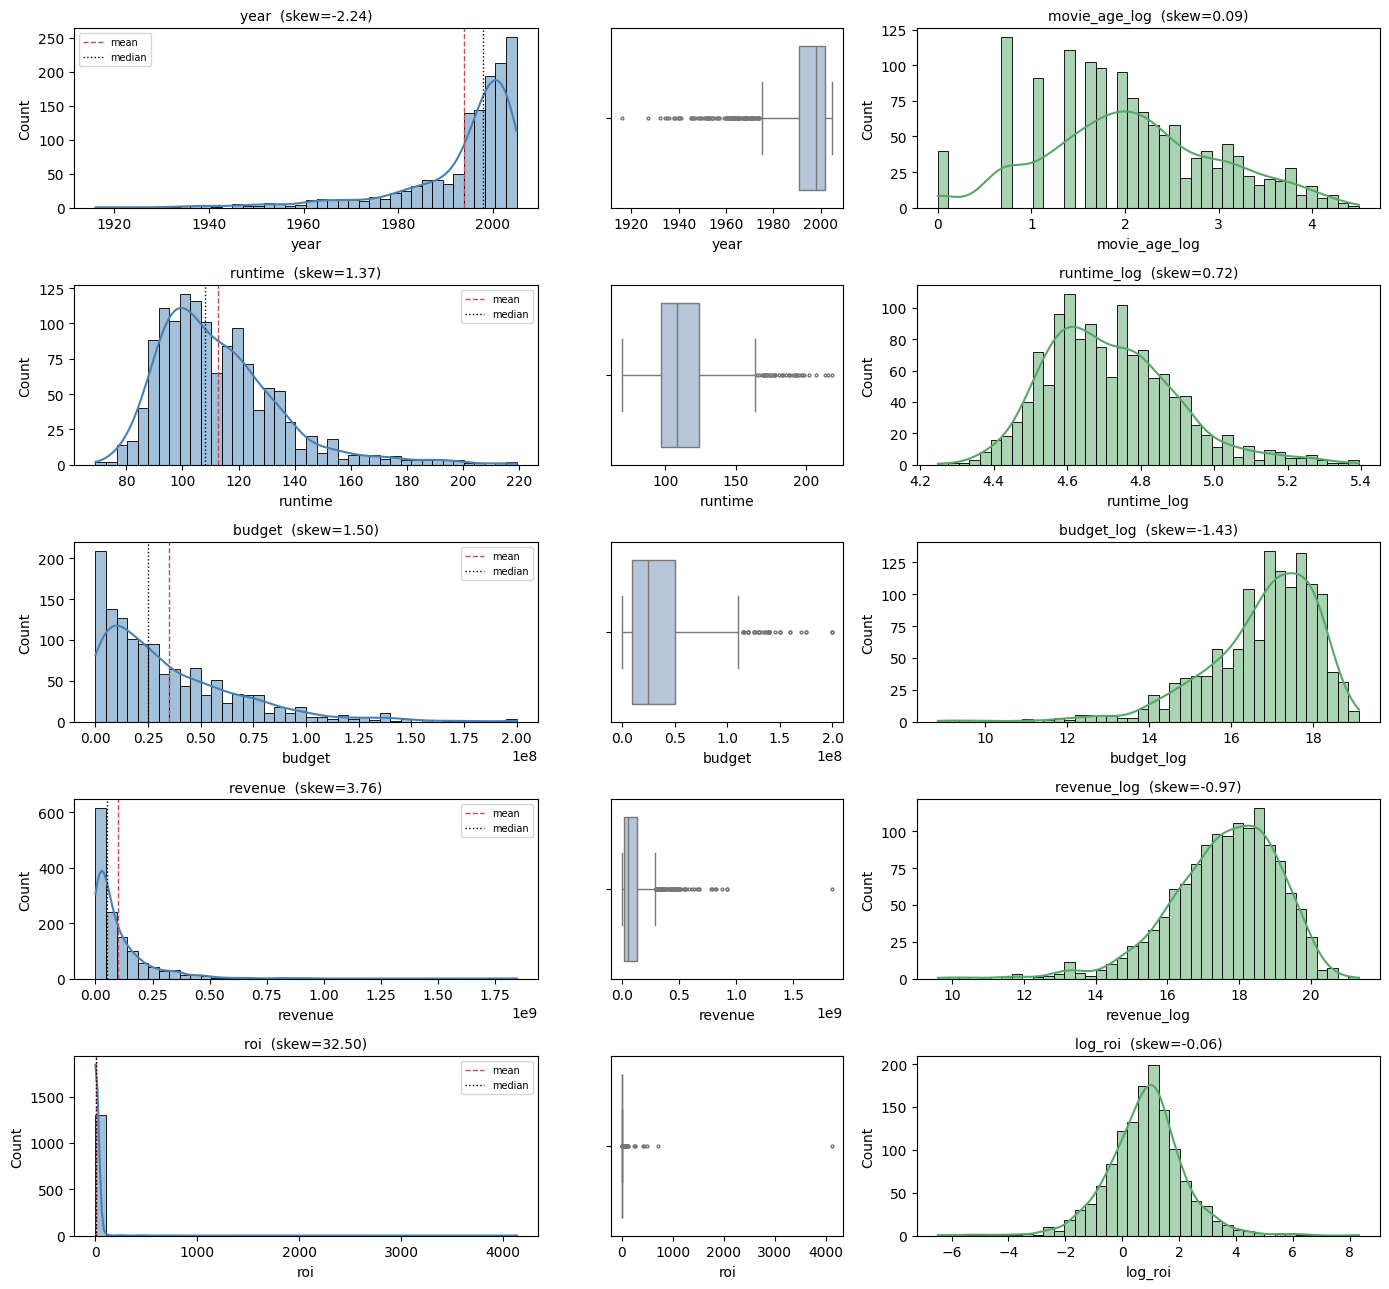

In [104]:
money_ok = rated[(rated["budget"] >= MIN_MONEY) & (rated["revenue"] >= MIN_MONEY)].copy()
print("movies in the money panels:", len(money_ok))
plot_raw_and_log(
    [
        ("year", rated["year"], "movie_age_log", rated["movie_age_log"]),
        ("runtime", rated["runtime"], "runtime_log", rated["runtime_log"]),
        ("budget", money_ok["budget"], "budget_log", money_ok["budget_log"]),
        ("revenue", money_ok["revenue"], "revenue_log", money_ok["revenue_log"]),
        ("roi", money_ok["roi"], "log_roi", money_ok["log_roi"]),
    ]
)

## 7. Collinearity

`year` and `movie_age` move together exactly, and `movie_age_log` is a transform of that same age. Budget, revenue, and ROI also overlap. The heatmap is Spearman on movies with budget and revenue of at least 1000$

In [105]:
age_cols = ["year", "movie_age", "movie_age_log"]
print("age")
rated[age_cols].corr(method="spearman").round(3)

age


,year,movie_age,movie_age_log
year,1.0,-1.0,-1.0
movie_age,-1.0,1.0,1.0
movie_age_log,-1.0,1.0,1.0


In [106]:
money_cols = ["budget_log", "revenue_log", "log_roi"]
print("money")
money_ok[money_cols].corr(method="spearman").round(3)

money


,budget_log,revenue_log,log_roi
budget_log,1.000,0.583,-0.297
revenue_log,0.583,1.000,0.530
log_roi,-0.297,0.530,1.000


In [107]:
heat_cols = [
    "year",
    "movie_age",
    "runtime",
    "budget",
    "revenue",
    "roi",
    "n_ratings",
    "avg_rating",
    "rating_std",
]
corr = money_ok[heat_cols].corr(method="spearman")

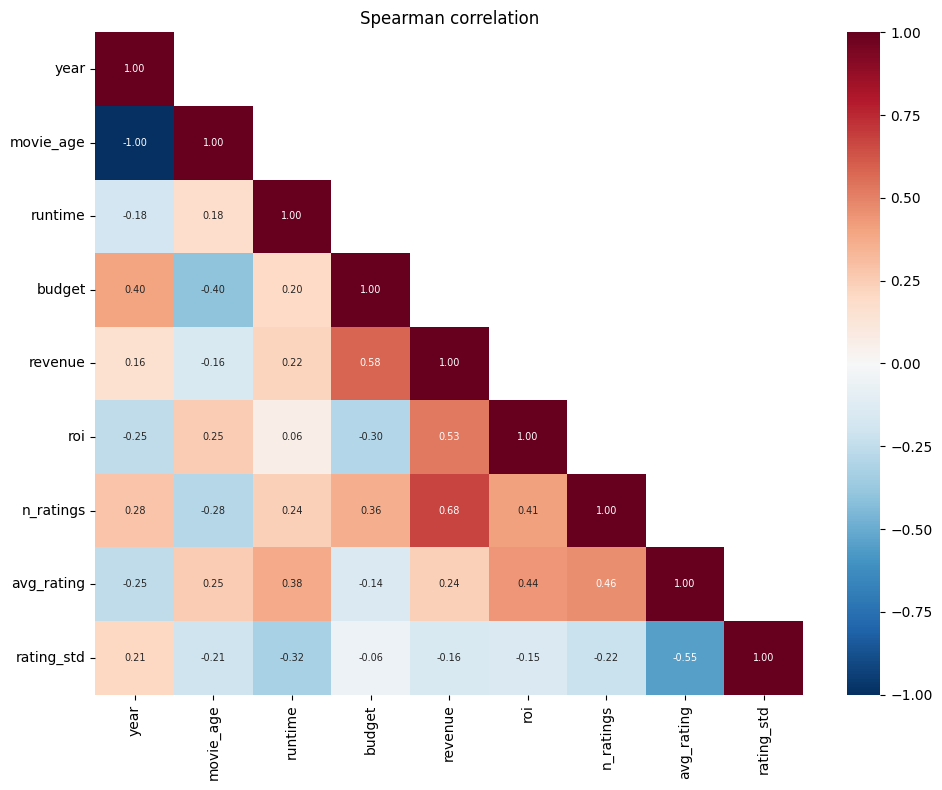

In [108]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Spearman correlation")
fig.tight_layout()
plt.show()

## Plot helpers

Bar charts, coverage curves, and rating box plots used from the genre section onward.

In [109]:
def explode_counts(lists):
    return lists.explode().dropna().value_counts()


def cap_tick_labels(levels, cap):
    return [f"{level}+" if level == cap else str(level) for level in levels]


def plot_top_bar(counts, n, title, xlabel="movies"):
    top = counts.head(n)[::-1]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.26 * len(top))))
    ax.barh(top.index.astype(str), top.values, color="steelblue")
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

In [110]:
def per_movie_count_bar(lists, title, cap=10):
    counts = lists.map(len).clip(upper=cap).value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(cap_tick_labels(counts.index, cap), counts.values, color="steelblue")
    ax.set_xlabel("items per movie")
    ax.set_ylabel("movies")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

In [111]:
def hits_any(lists, names):
    chosen = set(names)
    return lists.map(lambda items: any(item in chosen for item in items))


def coverage_table(lists, counts, xs):
    total_mentions = counts.sum()
    rows = []
    for x in xs:
        has_top = hits_any(lists, counts.index[:x])
        rows.append(
            {
                "X": x,
                "min_movies": int(counts.iloc[x - 1]),
                "pct_movies": 100 * has_top.mean(),
                "pct_mentions": 100 * counts.iloc[:x].sum() / total_mentions,
            }
        )
    return pd.DataFrame(rows).set_index("X").round(1)

In [112]:
def plot_coverage(lists, counts, max_x, marks, title):
    xs = list(range(1, min(max_x, len(counts)) + 1))
    cov = coverage_table(lists, counts, xs)
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(cov.index, cov["pct_movies"], color="steelblue", label="% movies with a top-X item")
    ax.plot(cov.index, cov["pct_mentions"], color="#dd8452", label="% of mentions covered")
    for mark in marks:
        if mark in cov.index:
            ax.axvline(mark, color="gray", ls=":", lw=0.8)
    ax.set_xlabel("X = most frequent items kept")
    ax.set_ylabel("%")
    ax.set_ylim(0, 100)
    ax.legend(loc="lower right", fontsize=8)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

In [113]:
def ratings_by_median(groups):
    present = {}
    for label, values in groups.items():
        values = values.dropna()
        if len(values):
            present[label] = values
    return dict(sorted(present.items(), key=lambda item: item[1].median()))

In [114]:
def rating_boxplot(groups, title, ref=None):
    fig, ax = plt.subplots(figsize=(8, max(3, 0.32 * len(groups))))
    ax.boxplot(
        list(groups.values()),
        orientation="horizontal",
        patch_artist=True,
        boxprops={"facecolor": "lightsteelblue"},
        flierprops={"markersize": 2},
    )
    ax.set_yticks(range(1, len(groups) + 1))
    ax.set_yticklabels([f"{label} (n={len(values)})" for label, values in groups.items()])
    if ref is not None:
        ax.axvline(ref, color="#c44e52", ls="--", lw=1, label=f"median = {ref:.2f}")
        ax.legend(fontsize=8, loc="lower right")
    ax.set_xlabel("avg_rating")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

## 8. Genres

A movie can carry several genres. The bars are frequency and genres per movie, the heatmap is co-occurrence, and the boxes are the rating in each genre. `Foreign` is rare. `Documentary` is uncommon as a tag but is kept later because those films still draw many ratings.

In [115]:
genre_counts = explode_counts(movies["genre_names"])
print(genre_counts.to_string())

genre_names
Drama              602
Comedy             477
Thriller           393
Action             389
Adventure          268
Romance            262
Crime              243
Science Fiction    178
Mystery            132
Horror             129
Family             122
Fantasy            115
History             66
War                 57
Animation           46
Music               42
Western             35
Documentary         10
Foreign              1


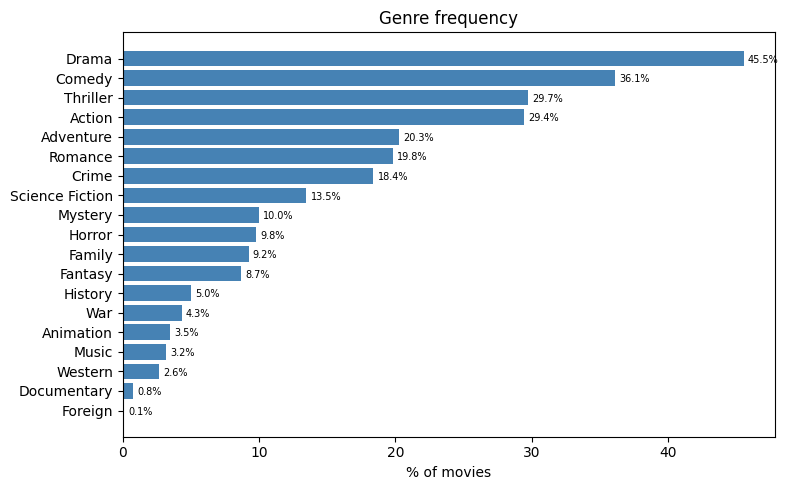

In [116]:
fig, ax = plt.subplots(figsize=(8, 5))
pct = 100 * genre_counts[::-1] / len(movies)
ax.barh(pct.index, pct.values, color="steelblue")
for y, value in enumerate(pct.values):
    ax.annotate(f"{value:.1f}%", (value, y), xytext=(3, -3), textcoords="offset points", fontsize=7)
ax.set_xlabel("% of movies")
ax.set_title("Genre frequency")
fig.tight_layout()
plt.show()

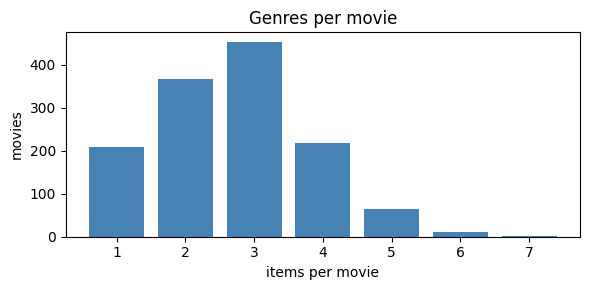

In [117]:
per_movie_count_bar(movies["genre_names"], "Genres per movie", cap=8)

In [118]:
def genre_indicators(genre_lists, genre_order):
    dummies = pd.get_dummies(genre_lists.explode()).groupby(level=0).max()
    return (
        dummies.reindex(index=genre_lists.index, columns=genre_order).fillna(0).astype(int)
    )

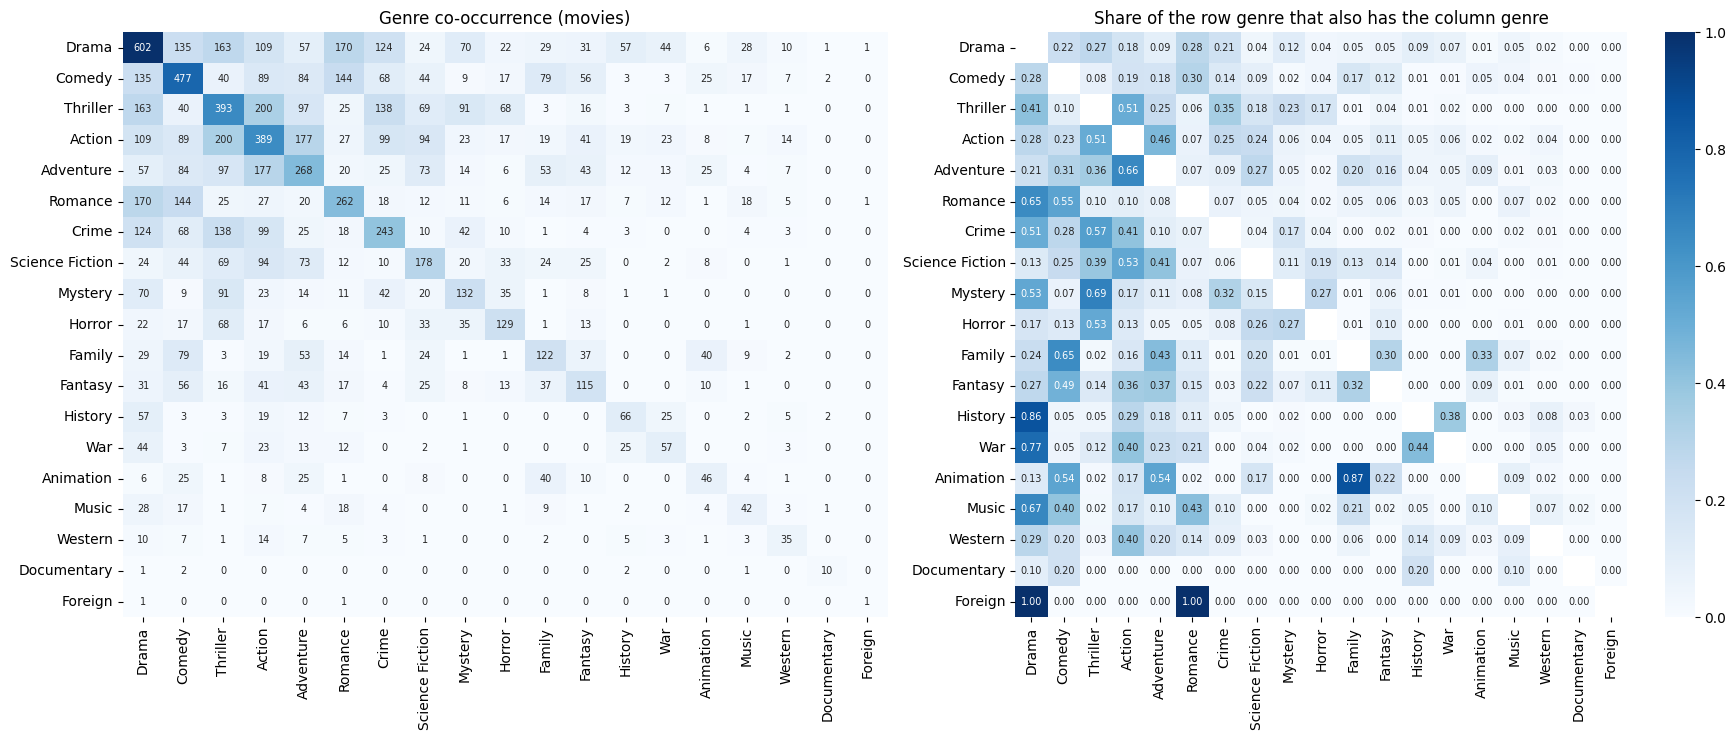

In [119]:
genre_order = list(genre_counts.index)
genre_dummies = genre_indicators(movies["genre_names"], genre_order)
co = genre_dummies.T @ genre_dummies
co_share = co.div(np.diag(co), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
sns.heatmap(co, annot=True, fmt="d", cmap="Blues", ax=axes[0], cbar=False, annot_kws={"fontsize": 7})
axes[0].set_title("Genre co-occurrence (movies)")
off = co_share.where(~np.eye(len(co_share), dtype=bool))
sns.heatmap(
    off, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1], annot_kws={"fontsize": 7}
)
axes[1].set_title("Share of the row genre that also has the column genre")
fig.tight_layout()
plt.show()

In [120]:
pairs = off.stack()
shared = co.stack().reindex(pairs.index)
print(pairs[shared >= 10].sort_values(ascending=False).head(10).round(2).to_string())

Animation  Family      0.87
History    Drama       0.86
War        Drama       0.77
Mystery    Thriller    0.69
Music      Drama       0.67
Adventure  Action      0.66
Romance    Drama       0.65
Family     Comedy      0.65
Crime      Thriller    0.57
Romance    Comedy      0.55


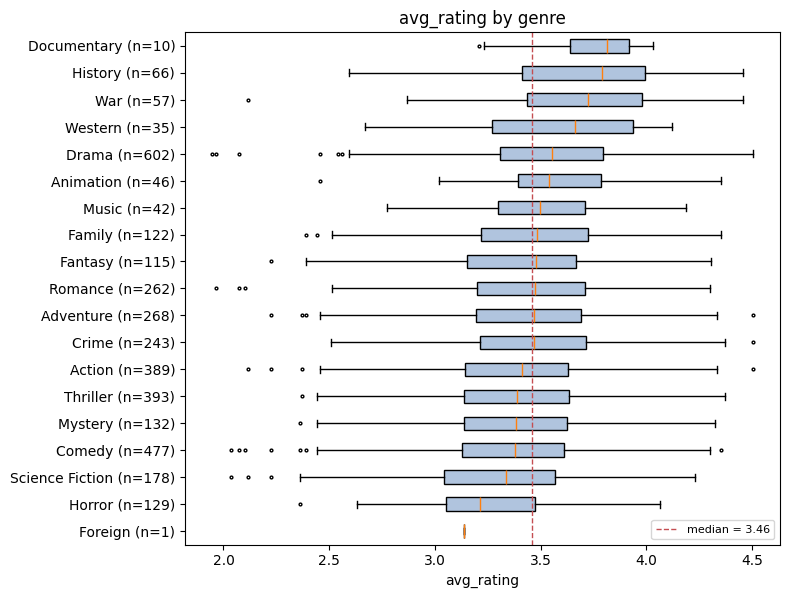

In [121]:
genre_ratings = ratings_by_median(
    {
        genre: rated.loc[genre_dummies.loc[rated.index, genre].eq(1), "avg_rating"]
        for genre in genre_order
    }
)
rating_boxplot(genre_ratings, "avg_rating by genre", ref=rated["avg_rating"].median())

## 9. Production companies

Merge studio aliases, then see how many movies the most frequent names cover. The feature table keeps the top 15 after this merge. The first bar is before the merge, so repeated studio spellings are visible. The curve is top-X coverage after the merge.

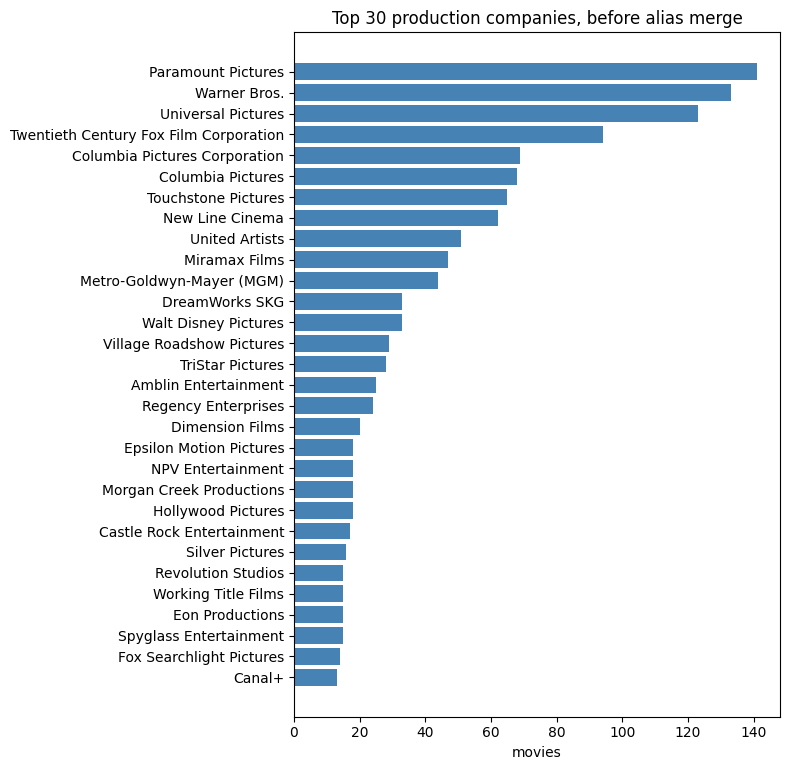

In [122]:
plot_top_bar(
    explode_counts(movies["company_names"]),
    30,
    "Top 30 production companies, before alias merge",
)

In [123]:
COMPANY_ALIASES = {
    "Columbia Pictures Corporation": "Columbia Pictures",
    "Paramount": "Paramount Pictures",
    "Warner Bros. Pictures": "Warner Bros.",
    "Universal Studios": "Universal Pictures",
    "Universal Pictures Corporation": "Universal Pictures",
    "Miramax": "Miramax Films",
    "Walt Disney": "Walt Disney Pictures",
    "Walt Disney Productions": "Walt Disney Pictures",
    "DreamWorks": "DreamWorks SKG",
    "DreamWorks Pictures": "DreamWorks SKG",
    "Polygram Filmed Entertainment": "PolyGram Filmed Entertainment",
    "Lions Gate": "Lions Gate Films",
    "Malpaso Company": "Malpaso Productions",
    "Cruise-Wagner Productions": "Cruise/Wagner Productions",
    "Mandalay Pictures": "Mandalay Entertainment",
    "Zanuck Company, The": "The Zanuck Company",
    "Kennedy/Marshall Company, The": "The Kennedy/Marshall Company",
}

In [124]:
def canonical_company_names(names):
    merged = (COMPANY_ALIASES.get(name, name) for name in names)
    return list(dict.fromkeys(merged))

In [125]:
companies = movies["company_names"].map(canonical_company_names)
company_counts = explode_counts(companies)
top15 = company_counts.index[:15]
print("companies after alias merge:", int(company_counts.shape[0]))
print(f"share of movies with a top-15 company: {hits_any(companies, top15).mean():.1%}")
print(company_counts.head(15).to_string())

companies after alias merge: 1397
share of movies with a top-15 company: 72.8%
company_names
Paramount Pictures                        143
Columbia Pictures                         136
Warner Bros.                              136
Universal Pictures                        126
Twentieth Century Fox Film Corporation     94
Touchstone Pictures                        65
New Line Cinema                            62
Miramax Films                              55
United Artists                             51
Metro-Goldwyn-Mayer (MGM)                  44
Walt Disney Pictures                       42
DreamWorks SKG                             39
Village Roadshow Pictures                  29
TriStar Pictures                           28
Amblin Entertainment                       25


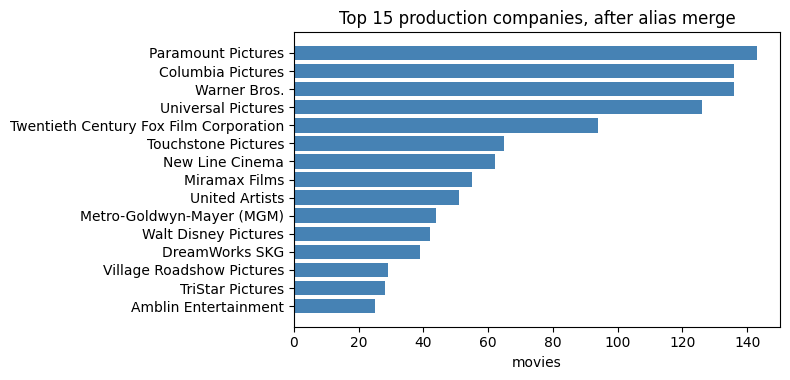

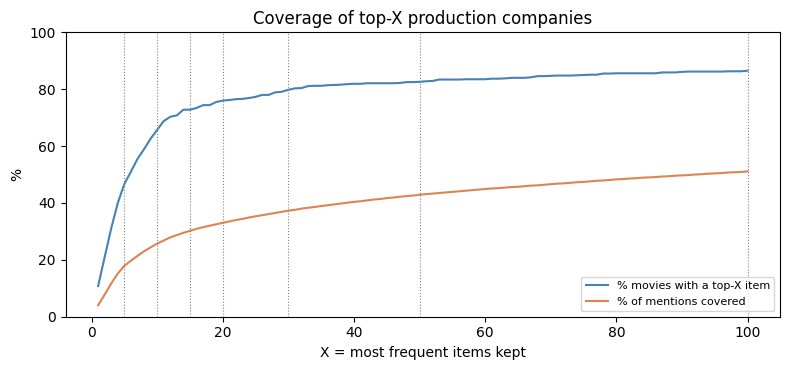

movies of the X-th company: {10: 44, 15: 25, 20: 18, 30: 13, 50: 8}


In [126]:
plot_top_bar(company_counts, 15, "Top 15 production companies, after alias merge")
plot_coverage(
    companies,
    company_counts,
    max_x=100,
    marks=[5, 10, 15, 20, 30, 50, 100],
    title="Coverage of top-X production companies",
)
kept = [x for x in [10, 15, 20, 30, 50] if x <= len(company_counts)]
print("movies of the X-th company:", {x: int(company_counts.iloc[x - 1]) for x in kept})

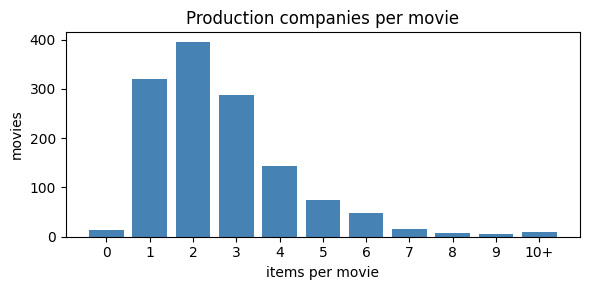

In [127]:
per_movie_count_bar(companies, "Production companies per movie")

In [128]:
def lists_contain(lists, name):
    return lists.map(lambda names: name in names)

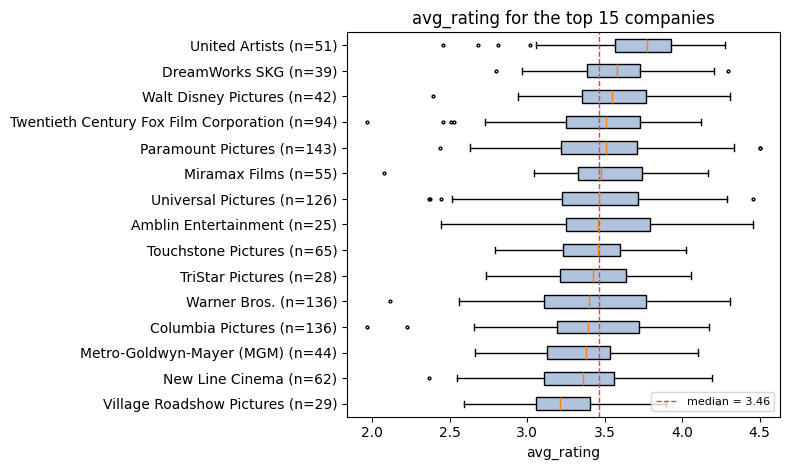

In [129]:
company_ratings = ratings_by_median(
    {
        name: rated.loc[lists_contain(companies.loc[rated.index], name), "avg_rating"]
        for name in company_counts.index[:15]
    }
)
rating_boxplot(
    company_ratings,
    "avg_rating for the top 15 companies",
    ref=rated["avg_rating"].median(),
)

## 10. Production countries

The United States appears on most films, so the feature table uses three groups instead of a long one-hot list: US only, US co-production, and non-US. The plots show the long tail, top-X coverage, and the rating in each group.

In [130]:
def country_group(names):
    if not names:
        return "no country"
    if names == [US]:
        return "us_only"
    if US in names:
        return "us_coproduction"
    return "non_us"

In [131]:
has_us = movies["country_names"].map(lambda names: US in names)
print(f"movies listing the US: {has_us.mean():.1%}")
groups = movies["country_names"].map(country_group)
groups.name = None
print(groups.value_counts().to_string())

movies listing the US: 93.1%
us_only            948
us_coproduction    283
non_us              86
no country           5


unique countries: 42


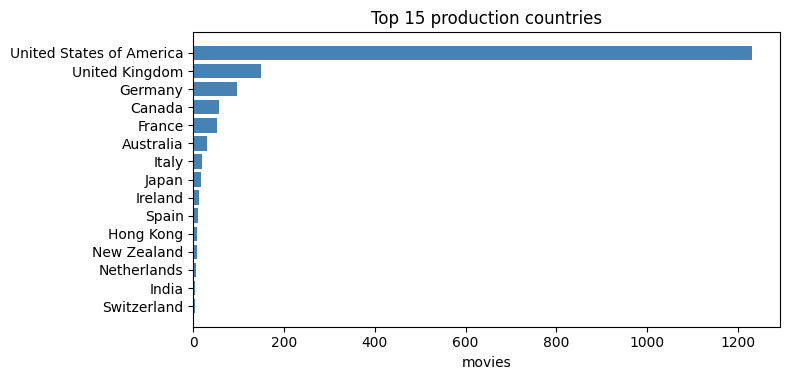

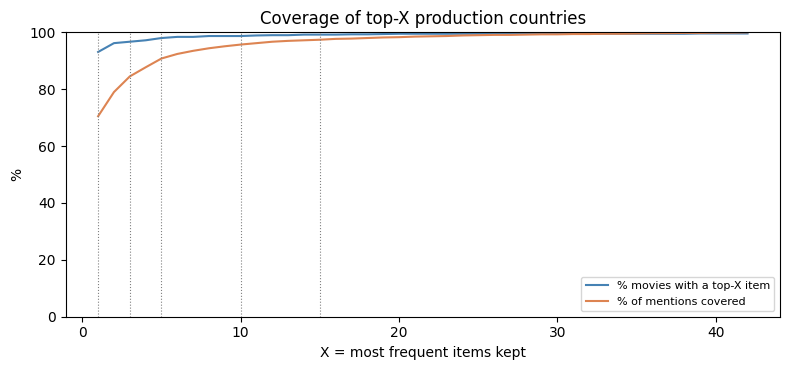

In [132]:
country_counts = explode_counts(movies["country_names"])
print("unique countries:", len(country_counts))
plot_top_bar(country_counts, 15, "Top 15 production countries")
plot_coverage(
    movies["country_names"],
    country_counts,
    max_x=len(country_counts),
    marks=[1, 3, 5, 10, 15],
    title="Coverage of top-X production countries",
)

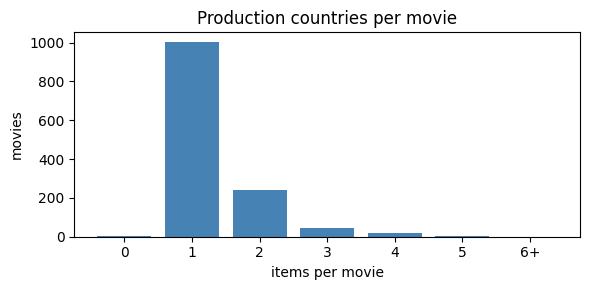

In [133]:
per_movie_count_bar(movies["country_names"], "Production countries per movie", cap=6)

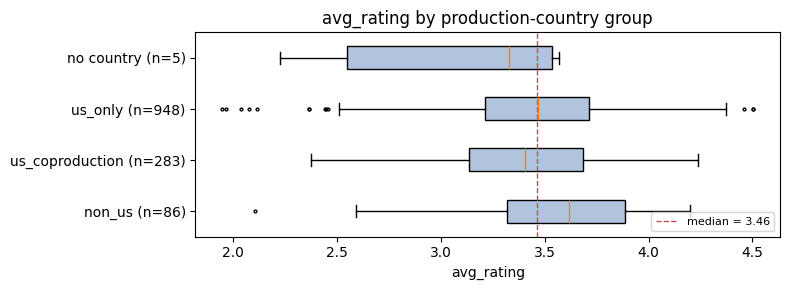

In [134]:
order = [
    label
    for label in ["non_us", "us_coproduction", "us_only", "no country"]
    if (groups == label).any()
]
rating_boxplot(
    {
        label: rated.loc[groups.reindex(rated.index).eq(label), "avg_rating"].dropna()
        for label in order
    },
    "avg_rating by production-country group",
    ref=rated["avg_rating"].median(),
)

## 11. Language

English dominates the original language, so one flag is enough. A second flag marks films with more than one spoken language. The bars are the language counts, and the boxes compare those two flags.

In [135]:
print(f"original language English: {(movies['original_language'] == 'en').mean():.1%}")
print(f"two or more spoken languages: {movies['language_names'].map(len).gt(1).mean():.1%}")
print(movies["original_language"].value_counts().head(8).to_string())

original language English: 97.5%
two or more spoken languages: 34.3%
original_language
en    1289
de       6
ja       5
fr       5
it       4
es       3
cn       3
pt       2


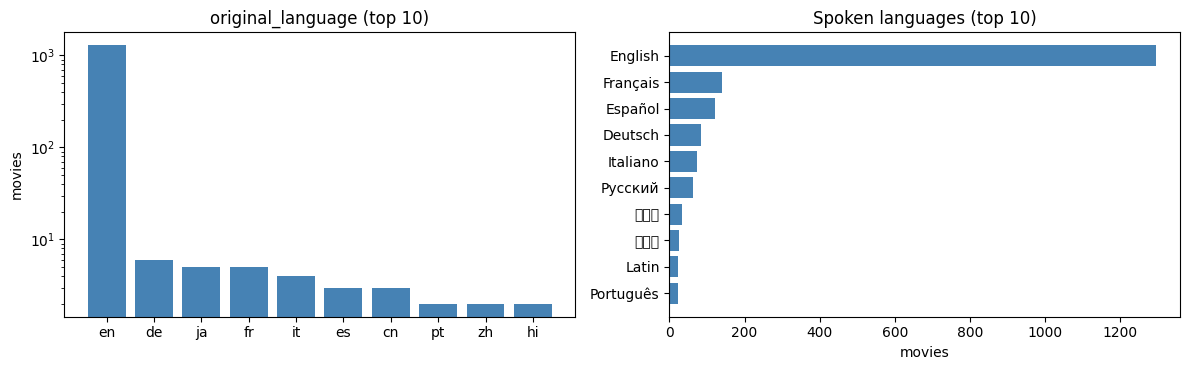

In [136]:
# One original-language label is in Chinese script, which the default font cannot draw.
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
orig = movies["original_language"].value_counts().head(10)
axes[0].bar(orig.index.astype(str), orig.values, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("original_language (top 10)")
axes[0].set_ylabel("movies")
spoken = explode_counts(movies["language_names"]).head(10)
axes[1].barh(spoken.index[::-1].astype(str), spoken.values[::-1], color="steelblue")
axes[1].set_title("Spoken languages (top 10)")
axes[1].set_xlabel("movies")
fig.tight_layout()
plt.show()

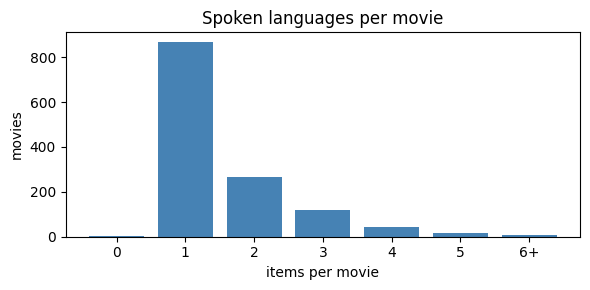

In [137]:
per_movie_count_bar(movies["language_names"], "Spoken languages per movie", cap=6)

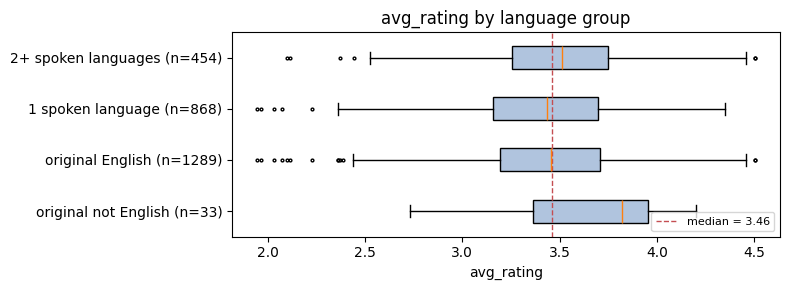

In [138]:
lang_groups = {
    "original not English": rated.loc[rated["original_language"] != "en", "avg_rating"],
    "original English": rated.loc[rated["original_language"] == "en", "avg_rating"],
    "1 spoken language": rated.loc[rated["language_names"].map(len) <= 1, "avg_rating"],
    "2+ spoken languages": rated.loc[rated["language_names"].map(len) > 1, "avg_rating"],
}
rating_boxplot(lang_groups, "avg_rating by language group", ref=rated["avg_rating"].median())

## 12. Director and cast scores

These scores describe the people on a movie using the other films they worked on in this table. The tables and the line chart show which version moves with `avg_rating` and `rating_std`.

**Film count** is how many movies here that director worked on.

**Track record** is that person's usual rating. For the movie being scored, the mean ratings of their other films are averaged, then pulled toward the overall mean when they have only a few other films. With the pull set at 3, three other films sit halfway between their own average and the overall mean. The movie itself is left out. A second version counts only films released in earlier years.

**Experience** is how many other movies here that actor appears in. **Exposure** is how widely those other movies were rated: the log of their average number of ratings. Actor track record uses the same pull as for directors. Actors are listed in billing order, and for a chosen k the score is the average of the first k names.

Most directors in this table appear on only one movie, so a score that needs several other films is missing for them. The following charts show how many directors it takes to cover the movies, and the 15 names that appear most often.

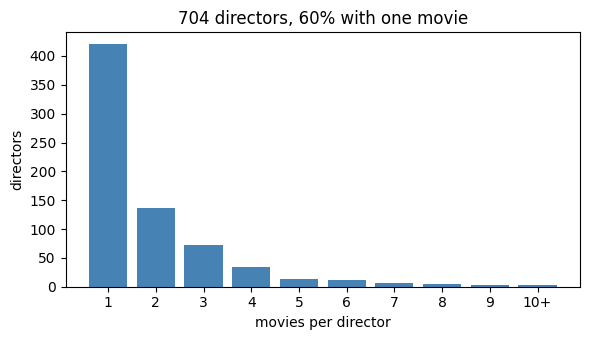

In [139]:
director_counts = movies["director"].dropna().value_counts()
fig, ax = plt.subplots(figsize=(6, 3.5))
dist = director_counts.clip(upper=10).value_counts().sort_index()
ax.bar(cap_tick_labels(dist.index, 10), dist.values, color="steelblue")
ax.set_xlabel("movies per director")
ax.set_ylabel("directors")
share_once = (director_counts == 1).mean()
ax.set_title(f"{len(director_counts):,} directors, {share_once:.0%} with one movie")
fig.tight_layout()
plt.show()

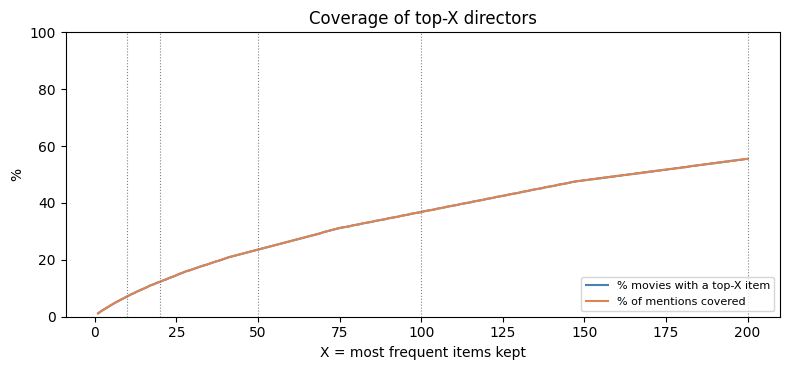

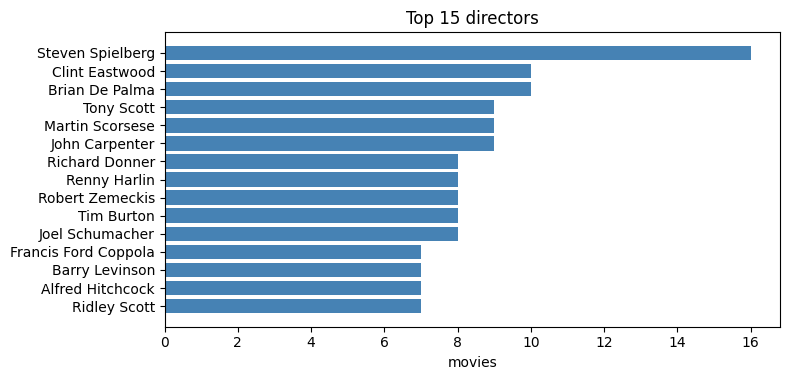

In [140]:
director_lists = movies["director"].map(lambda name: [name] if isinstance(name, str) else [])
plot_coverage(
    director_lists,
    director_counts,
    max_x=200,
    marks=[10, 20, 50, 100, 200],
    title="Coverage of top-X directors",
)
plot_top_bar(director_counts, 15, "Top 15 directors")

The first boxes are the mean rating for the 15 directors with the most films here. The second boxes group every movie by how many films its director has in this table. The line is the median mean rating of all rated movies.

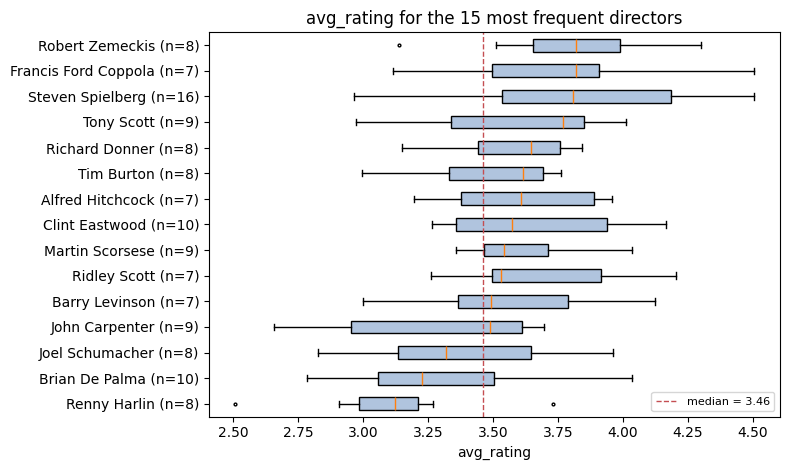

In [141]:
director_ratings = ratings_by_median(
    {
        name: rated.loc[rated["director"].eq(name), "avg_rating"]
        for name in director_counts.index[:15]
    }
)
rating_boxplot(
    director_ratings,
    "avg_rating for the 15 most frequent directors",
    ref=rated["avg_rating"].median(),
)

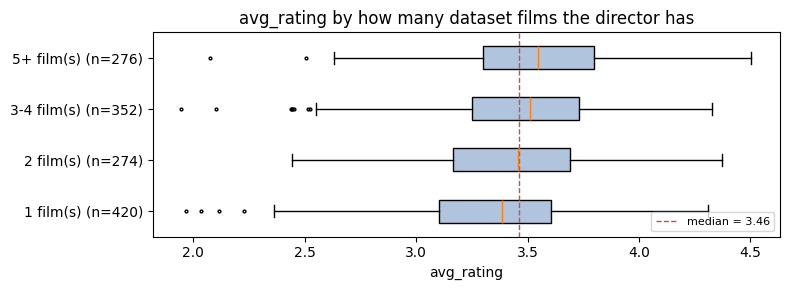

In [142]:
films = rated["director"].map(director_counts)
bucket = pd.cut(films, [0, 1, 2, 4, np.inf], labels=["1", "2", "3-4", "5+"])
by_count = {
    f"{label} film(s)": rated.loc[bucket.eq(label), "avg_rating"].dropna()
    for label in ["1", "2", "3-4", "5+"]
}
rating_boxplot(
    {label: values for label, values in by_count.items() if len(values)},
    "avg_rating by how many dataset films the director has",
    ref=rated["avg_rating"].median(),
)

In [143]:
def track_record(pairs, global_mean, shrink=SHRINK, prior_only=False):
    """Shrunk mean avg_rating of each person's other films, and how many of those films."""
    if prior_only:
        by_year = pairs.groupby(["person", "year"])["avg_rating"].agg(["sum", "count"])
        earlier = by_year.groupby(level=0).cumsum() - by_year
        joined = pairs.join(earlier, on=["person", "year"])
        other_sum, other_n = joined["sum"], joined["count"]
    else:
        totals = pairs.groupby("person")["avg_rating"].agg(["sum", "count"])
        joined = pairs.join(totals, on="person")
        other_sum = joined["sum"] - joined["avg_rating"]
        other_n = joined["count"] - 1
    score = (other_sum + shrink * global_mean) / (other_n + shrink)
    return score, other_n

Each row is one director score. The numbers are how strongly it moves with `avg_rating` and with `rating_std`. A larger absolute value is a tighter link.

In [144]:
GLOBAL_MEAN = rated["avg_rating"].mean()
director_pairs = rated.dropna(subset=["director"])[
    ["netflix_movie_id", "director", "avg_rating", "year"]
].rename(columns={"director": "person"})
dir_counts = director_pairs["person"].value_counts()
rated["director_film_count"] = rated["director"].map(dir_counts)
score, _ = track_record(director_pairs, GLOBAL_MEAN)
prior, _ = track_record(director_pairs, GLOBAL_MEAN, prior_only=True)
director_scores = director_pairs[["netflix_movie_id"]].copy()
director_scores["director_track_record"] = score.to_numpy()
director_scores["director_track_record_prior"] = prior.to_numpy()
rated = rated.merge(director_scores, on="netflix_movie_id", how="left")

In [145]:
director_score_cols = [
    ("film_count", "director_film_count"),
    ("track_record", "director_track_record"),
    ("track_record_prior", "director_track_record_prior"),
]
director_table = pd.DataFrame(
    [
        {
            "who": "director",
            "score": name,
            "k": np.nan,
            "avg_rating": rated[col].corr(rated["avg_rating"], method="spearman"),
            "rating_std": rated[col].corr(rated["rating_std"], method="spearman"),
        }
        for name, col in director_score_cols
    ]
)
director_table.round(3)

,who,score,k,avg_rating,rating_std
0,director,film_count,NaN,0.168,-0.206
1,director,track_record,NaN,0.220,-0.196
2,director,track_record_prior,NaN,0.177,-0.172


### Cast

How large the billed cast is, whether the actor in each billing slot also appears in another movie here, and how many movies each actor has. Position 0 is the lead.

In [146]:
def lead_name(names):
    return names[0] if names else np.nan


def share_with_another_film(cast_names, actor_counts, n_positions=10):
    sizes = cast_names.map(len)
    shares = []
    for position in range(1, n_positions + 1):
        billed = cast_names.loc[sizes >= position]
        has_other = billed.map(
            lambda names, position=position: actor_counts.get(names[position - 1], 0) > 1
        )
        shares.append(100 * has_other.mean())
    return shares

In [147]:
def plot_films_per_actor(ax, counted):
    for label, counts, color in counted:
        share = counts.clip(upper=10).value_counts(normalize=True).sort_index() * 100
        ax.plot(
            cap_tick_labels(share.index, 10),
            share.to_numpy(),
            marker="o",
            color=color,
            label=f"{label}: {(counts == 1).mean():.0%} once",
        )

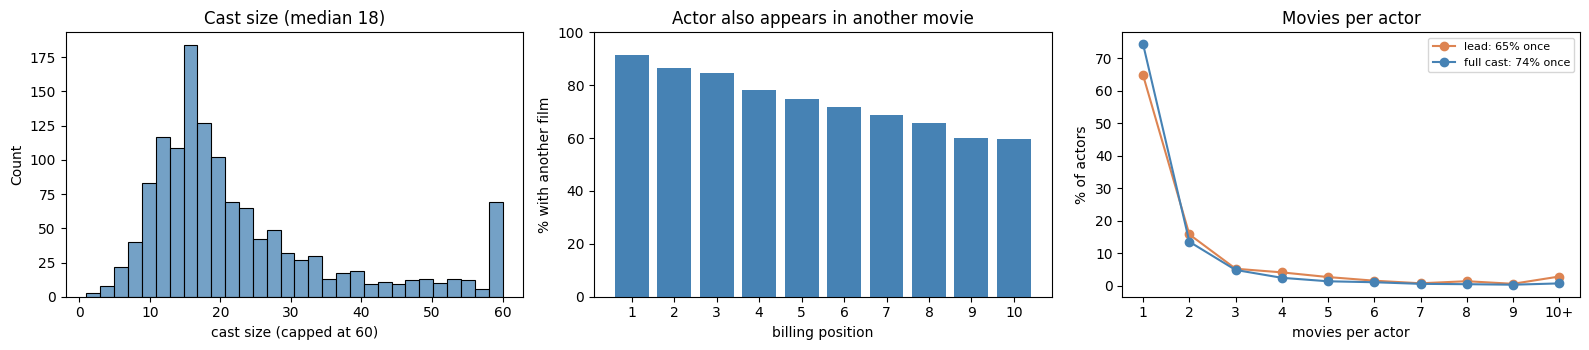

In [148]:
actor_counts = explode_counts(movies["cast_names"])
lead_counts = movies["cast_names"].map(lead_name).dropna().value_counts()
sizes = movies["cast_names"].map(len)
also_known = share_with_another_film(movies["cast_names"], actor_counts)
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
sns.histplot(sizes.clip(upper=60), bins=30, color="steelblue", ax=axes[0])
axes[0].set_xlabel("cast size (capped at 60)")
axes[0].set_title(f"Cast size (median {sizes.median():.0f})")
axes[1].bar([str(position) for position in range(1, 11)], also_known, color="steelblue")
axes[1].set_xlabel("billing position")
axes[1].set_ylabel("% with another film")
axes[1].set_ylim(0, 100)
axes[1].set_title("Actor also appears in another movie")
plot_films_per_actor(
    axes[2],
    [("lead", lead_counts, "#dd8452"), ("full cast", actor_counts, "steelblue")],
)
axes[2].set_xlabel("movies per actor")
axes[2].set_ylabel("% of actors")
axes[2].legend(fontsize=8)
axes[2].set_title("Movies per actor")
fig.tight_layout()
plt.show()

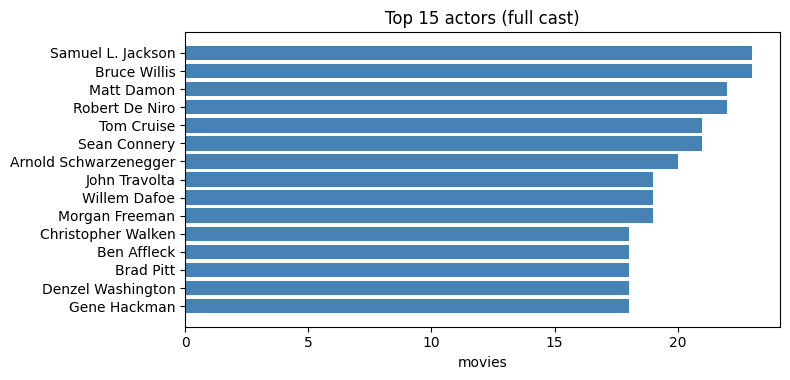

In [149]:
plot_top_bar(actor_counts, 15, "Top 15 actors (full cast)")

Same comparison as for directors, repeated for each k. Experience and exposure weaken as more billed names are averaged in.

In [150]:
def actor_scores(frame, k, global_mean, prior_only=False):
    pairs = frame[["netflix_movie_id", "cast_names", "avg_rating", "n_ratings", "year"]].copy()
    pairs["person"] = pairs["cast_names"].map(lambda names: names[:k])
    pairs = pairs.explode("person").dropna(subset=["person"]).drop(columns="cast_names")
    pairs["track_record"], other_n = track_record(pairs, global_mean, prior_only=prior_only)
    if prior_only:
        return pairs.groupby("netflix_movie_id")["track_record"].mean()
    popularity = pairs.groupby("person")["n_ratings"].transform("sum") - pairs["n_ratings"]
    pairs["experience"] = other_n
    pairs["exposure"] = np.where(other_n > 0, np.log1p(popularity / other_n.clip(lower=1)), 0)
    return pairs.groupby("netflix_movie_id")[["experience", "exposure", "track_record"]].mean()

In [151]:
K_VALUES = [1, 2, 3, 5, 7, 10]
target = rated.set_index("netflix_movie_id")[["avg_rating", "rating_std"]]
score_names = ["experience", "exposure", "track_record", "track_record_prior"]
actor_rows = []
for k in K_VALUES:
    scores = actor_scores(rated, k, GLOBAL_MEAN).join(
        actor_scores(rated, k, GLOBAL_MEAN, prior_only=True).rename("track_record_prior")
    )
    scores = scores.join(target)
    for score_name in score_names:
        actor_rows.append(
            {
                "who": "actor",
                "score": score_name,
                "k": k,
                "avg_rating": scores[score_name].corr(scores["avg_rating"], method="spearman"),
                "rating_std": scores[score_name].corr(scores["rating_std"], method="spearman"),
            }
        )
actor_table = pd.DataFrame(actor_rows)

The same actor scores, drawn against k. The track-record line strengthens as more billed actors are included. The dotted line uses only earlier releases.

In [152]:
styles = {
    "experience": ("#55a868", "-"),
    "exposure": ("#dd8452", "-"),
    "track_record": ("steelblue", "-"),
    "track_record_prior": ("steelblue", ":"),
}

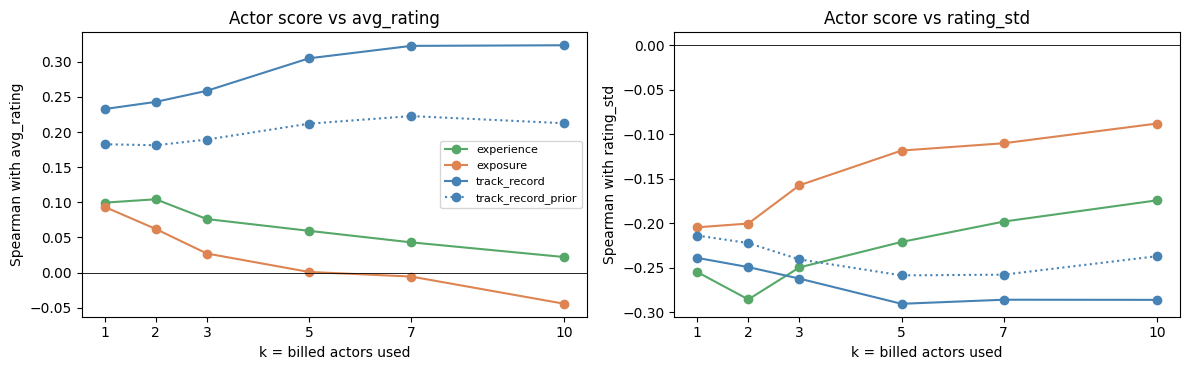

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, target_name in zip(axes, ["avg_rating", "rating_std"]):
    for score_name, (color, line_style) in styles.items():
        subset = actor_table[actor_table["score"] == score_name]
        ax.plot(
            subset["k"],
            subset[target_name],
            marker="o",
            color=color,
            ls=line_style,
            label=score_name,
        )
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xticks(K_VALUES)
    ax.set_xlabel("k = billed actors used")
    ax.set_ylabel(f"Spearman with {target_name}")
    ax.set_title(f"Actor score vs {target_name}")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 13. How feature groups line up with the rating

Each dot is the difference in mean rating between movies with and without that flag. Adjusted R² is how much of `avg_rating` one group explains on its own. The ranking is Spearman with `avg_rating`. The R² bars and the ranking use movies with budget and revenue of at least $1,000, so ROI is not dominated by entry errors. Cast scores in that comparison use the first 5 billed actors, the k used in `05_movie_features.ipynb`.

In [154]:
def indicator_effects(indicators, y):
    rows = []
    for (family, name), col in indicators.items():
        y1, y0 = y[col == 1], y[col == 0]
        if len(y1) < 5 or len(y0) < 2:
            continue
        diff = y1.mean() - y0.mean()
        se = np.sqrt(y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0))
        rows.append({"family": family, "name": name, "n": len(y1), "diff": diff, "ci": 1.96 * se})
    return pd.DataFrame(rows)


def adjusted_r2(X, y):
    design = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(design, y, rcond=None)
    residual = ((y - design @ beta) ** 2).sum()
    total = ((y - y.mean()) ** 2).sum()
    r2 = 1 - residual / total
    p = np.linalg.matrix_rank(design) - 1
    return 1 - (1 - r2) * (len(y) - 1) / (len(y) - p - 1)

In [155]:
def flag_contains(lists, name):
    return lists.map(lambda names: int(name in names))


def flag_has_outsider(lists, top):
    top = set(top)
    return lists.map(lambda names: int(any(name not in top for name in names)))

In [156]:
def movie_indicators(movies, genre_dummies, genre_order, companies, company_counts, groups):
    top15 = list(company_counts.index[:15])
    columns = {}
    for genre in genre_order:
        columns[("genre", genre)] = genre_dummies[genre]
    for name in top15:
        columns[("company", name)] = flag_contains(companies, name)
    columns[("company", "outside top 15")] = flag_has_outsider(companies, top15)
    for label in ["us_only", "us_coproduction", "non_us", "no country"]:
        columns[("country", label)] = groups.eq(label).astype(int)
    for name in ["United Kingdom", "Germany", "France", "Canada"]:
        columns[("country", name)] = flag_contains(movies["country_names"], name)
    columns[("language", "original English")] = movies["original_language"].eq("en").astype(int)
    columns[("language", "2+ spoken languages")] = movies["language_names"].map(len).gt(1).astype(int)
    indicators = pd.DataFrame(columns, index=movies.index)
    indicators.columns = pd.MultiIndex.from_tuples(indicators.columns, names=["family", "name"])
    return indicators

In [157]:
indicators = movie_indicators(
    movies, genre_dummies, genre_order, companies, company_counts, groups
)
print(f"{indicators.shape[1]} indicator columns")

45 indicator columns


In [158]:
FAMILY_COLORS = {
    "genre": "steelblue",
    "company": "#dd8452",
    "country": "#55a868",
    "language": "#8172b3",
}
rated_indicators = indicators.loc[rated.index]
effects = {
    target_name: indicator_effects(rated_indicators, rated[target_name])
    for target_name in ["avg_rating", "rating_std"]
}
order = effects["avg_rating"].sort_values(["family", "diff"]).reset_index(drop=True)
labels = [f"{row.family}: {row.name} (n={row.n})" for row in order.itertuples()]

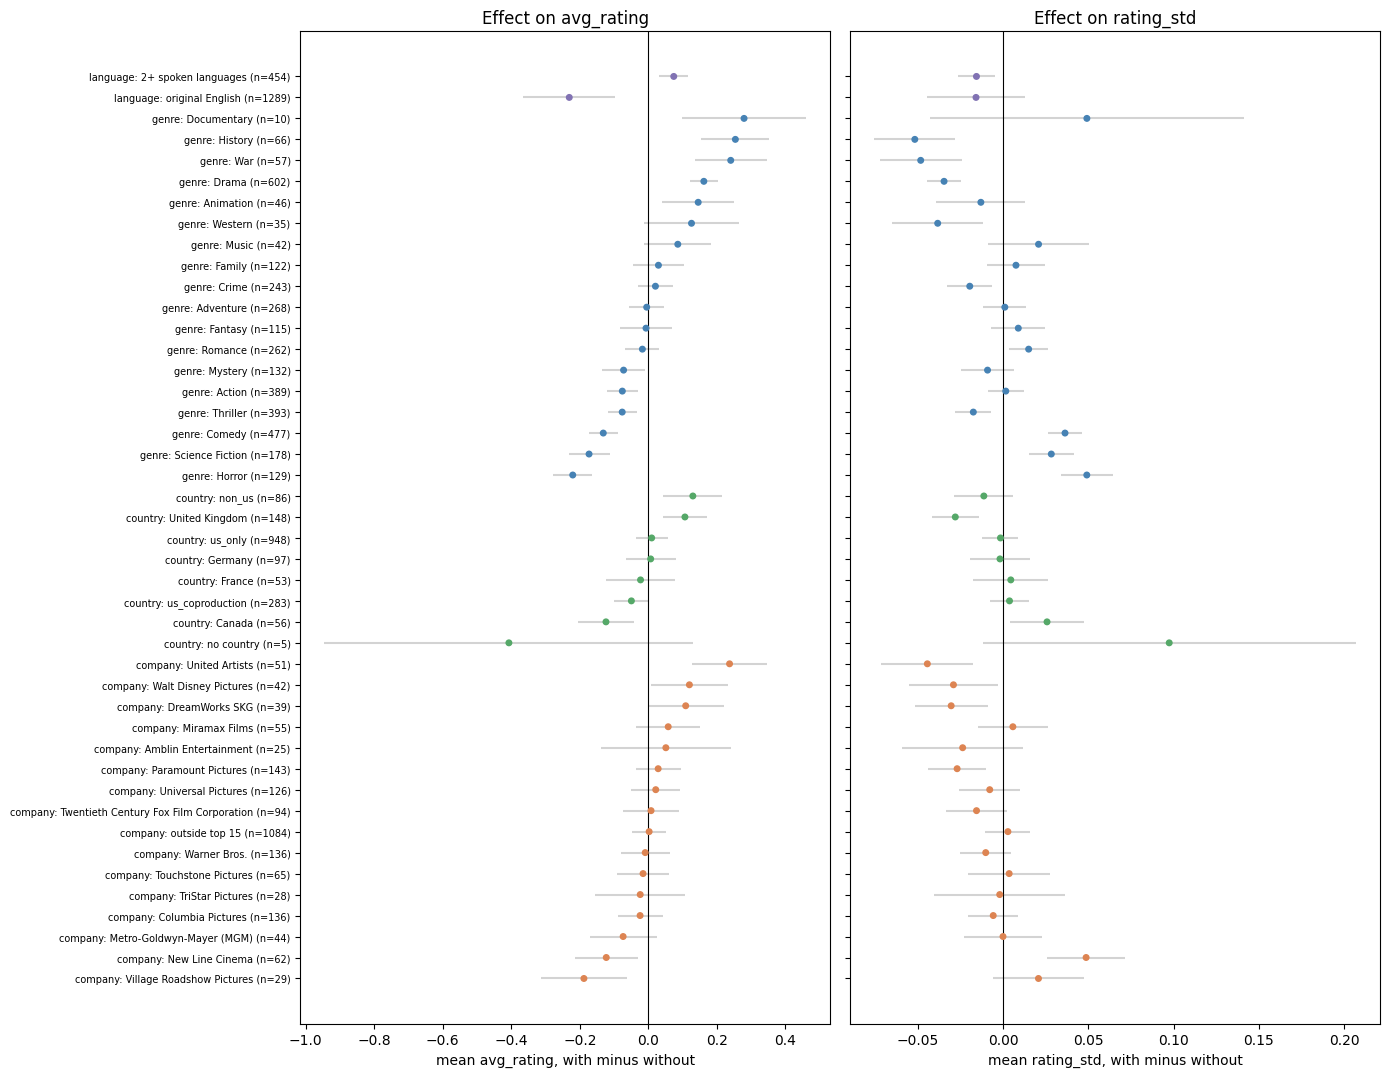

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(14, 0.22 * len(order) + 1.2), sharey=True)
for ax, target_name in zip(axes, ["avg_rating", "rating_std"]):
    aligned = effects[target_name].set_index(["family", "name"]).loc[
        list(zip(order["family"], order["name"]))
    ]
    ax.errorbar(
        aligned["diff"], range(len(aligned)), xerr=aligned["ci"], fmt="none", ecolor="lightgray"
    )
    ax.scatter(
        aligned["diff"],
        range(len(aligned)),
        c=[FAMILY_COLORS[family] for family in order["family"]],
        s=16,
        zorder=3,
    )
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel(f"mean {target_name}, with minus without")
    ax.set_title(f"Effect on {target_name}")
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(labels, fontsize=7)
fig.tight_layout()
plt.show()

In [160]:
CAST_K = 5  # billed actors used for cast_track_record in 05_movie_features
cast_detail = actor_scores(rated, CAST_K, GLOBAL_MEAN).add_prefix("cast_")
detail = rated.merge(cast_detail, left_on="netflix_movie_id", right_index=True, how="left")

In [161]:
fit_columns = [
    "runtime",
    "movie_age_log",
    "budget_log",
    "revenue_log",
    "log_roi",
    "director_track_record",
    "cast_track_record",
]
fit = detail.dropna(subset=fit_columns)
fit = fit[(fit["budget"] >= MIN_MONEY) & (fit["revenue"] >= MIN_MONEY)]
ind_fit = indicators.loc[fit.index]
y = fit["avg_rating"].to_numpy()

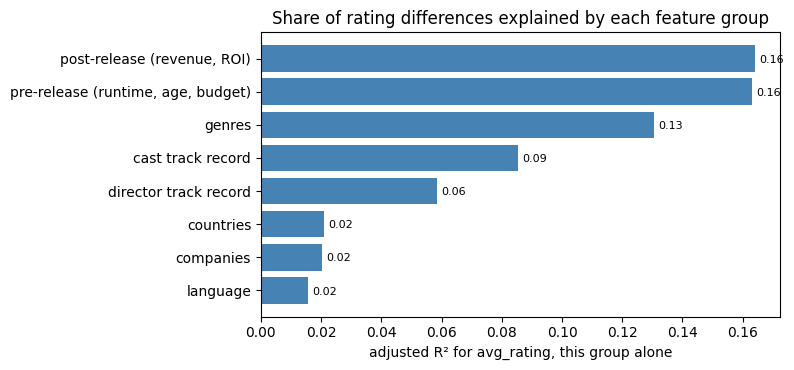

In [162]:
groups_r2 = {
    "genres": ind_fit["genre"],
    "companies": ind_fit["company"],
    "countries": ind_fit["country"],
    "language": ind_fit["language"],
    "pre-release (runtime, age, budget)": fit[["runtime", "movie_age_log", "budget_log"]],
    "post-release (revenue, ROI)": fit[["revenue_log", "log_roi"]],
    "director track record": fit[["director_track_record"]],
    "cast track record": fit[["cast_track_record"]],
}
group_r2 = pd.Series(
    {name: adjusted_r2(frame.to_numpy(dtype=float), y) for name, frame in groups_r2.items()}
).sort_values()
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(group_r2.index, group_r2.values, color="steelblue")
for i, value in enumerate(group_r2.values):
    ax.annotate(f"{value:.2f}", (value, i), xytext=(3, -3), textcoords="offset points", fontsize=8)
ax.set_xlabel("adjusted R² for avg_rating, this group alone")
ax.set_title("Share of rating differences explained by each feature group")
fig.tight_layout()
plt.show()

In [163]:
numeric_like = {
    "runtime": fit["runtime"],
    "movie_age_log": fit["movie_age_log"],
    "budget_log": fit["budget_log"],
    "revenue_log": fit["revenue_log"],
    "log_roi": fit["log_roi"],
    "director_film_count": fit["director_film_count"],
    "director_track_record": fit["director_track_record"],
    "cast_track_record": fit["cast_track_record"],
    "cast_experience": fit["cast_experience"],
    "cast_exposure": fit["cast_exposure"],
}
ranking_rows = []
for name, series in numeric_like.items():
    kind = "people" if name.startswith(("cast_", "director_")) else "numeric"
    ranking_rows.append((name, kind, series.corr(fit["avg_rating"], method="spearman")))
for (family, name), col in ind_fit.items():
    if col.sum() >= 5:
        ranking_rows.append(
            (f"{family}: {name}", family, col.corr(fit["avg_rating"], method="spearman"))
        )
ranking = pd.DataFrame(ranking_rows, columns=["feature", "type", "spearman"])

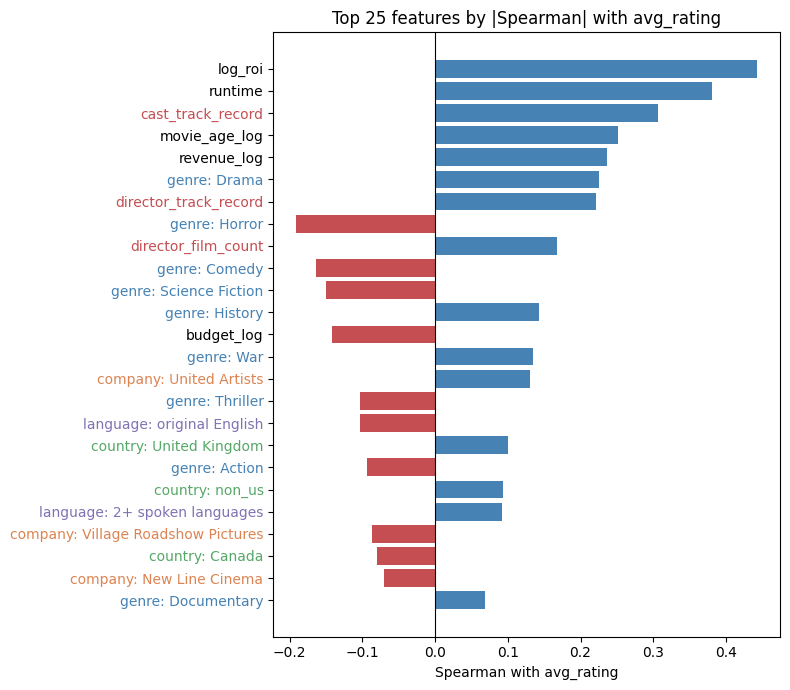

In [164]:
top = ranking.reindex(ranking["spearman"].abs().sort_values(ascending=False).index).head(25)[::-1]
type_colors = {"numeric": "black", "people": "#c44e52", **FAMILY_COLORS}
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["steelblue" if value > 0 else "#c44e52" for value in top["spearman"]]
ax.barh(top["feature"], top["spearman"], color=colors)
for tick, kind in zip(ax.get_yticklabels(), top["type"]):
    tick.set_color(type_colors[kind])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Spearman with avg_rating")
ax.set_title("Top 25 features by |Spearman| with avg_rating")
fig.tight_layout()
plt.show()

## Summary

- Zeros (TMDB's code for unknown budget, revenue or runtime) are removed earlier, in `03_clean_movies.ipynb`. Sub-$1,000 budget or revenue are entry errors; they stay visible here and are dropped in the feature notebook, along with missing runtime.
- `year`, raw `movie_age`, raw revenue, and `revenue_log` move with the columns that replace them, so the feature file keeps `movie_age_log`, `budget_log`, and `log_roi`. `year` itself is also kept, only for the train/test split strata.
- Genres stay multi-hot, with `Foreign` removed and `Documentary` kept. Companies use an alias merge and the top 15. Countries use US-only, US co-production, and non-US. Language uses `lang_en` and `is_multilingual`.
- People columns in the feature file are the director name and the first K billed actors. K = 5, set in the feature notebook. User rating buckets describe activity and scale use; they are not movie columns.